In [65]:
import pandas as pd

df = pd.read_csv(
    "data/lathe_job_status_data.csv",
    sep=";"
)

print(df.columns.tolist())
print(df.head())

['Current_Job_SLNo', 'Batch_PartNo', 'Part_SLNo', 'Component', 'Production_Started', 'Production_Completed', 'Avaliability', 'Performance', 'Quality', 'OEE', 'Planned_Sales', 'Income', 'Loss', 'Customer_ID', 'Project', 'Supervisor_ID']
   Current_Job_SLNo Batch_PartNo  Part_SLNo            Component  \
0                 1    RA-21-A-X          3  25/08/2025 12:19:00   
1                 2    RA-21-A-X          3  25/08/2025 19:53:00   
2                 3    RA-21-A-X          3  25/08/2025 20:06:00   
3                 4    RA-21-A-X          3  25/08/2025 20:32:00   
4                 5    RA-21-A-X          3  27/08/2025 14:45:00   

    Production_Started Production_Completed  Avaliability  Performance  \
0  25/08/2025 12:22:01           Base plate           100           99   
1  25/08/2025 19:56:30           Base plate            98           86   
2  25/08/2025 20:10:07           Base plate           100           73   
3  25/08/2025 20:35:59           Base plate            98  

In [66]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

df.columns.tolist()

['current_job_slno',
 'batch_partno',
 'part_slno',
 'component',
 'production_started',
 'production_completed',
 'avaliability',
 'performance',
 'quality',
 'oee',
 'planned_sales',
 'income',
 'loss',
 'customer_id',
 'project',
 'supervisor_id']

In [68]:
base_df = df[
    [
        "avaliability",
        "performance",
        "quality",
        "oee",
        "income",
        "loss",
    ]
].copy()

base_df

,avaliability,performance,quality,oee,income,loss
0,100,99,67,62,4000,2000
1,98,86,100,87,6000,0
2,100,73,100,70,6000,0
3,98,75,100,65,6000,0
4,100,33,67,34,4000,2000


In [69]:
base_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   avaliability  5 non-null      int64
 1   performance   5 non-null      int64
 2   quality       5 non-null      int64
 3   oee           5 non-null      int64
 4   income        5 non-null      int64
 5   loss          5 non-null      int64
dtypes: int64(6)
memory usage: 372.0 bytes


In [79]:
import random
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

rows = []

for _ in range(5000):

    speed = random.randint(7, 18)
    downtime_minutes = random.randint(0, 20)
    shutdown_minutes = random.randint(0, 30)

    machine_issue = np.random.choice(
        [0, 1],
        p=[0.95, 0.05]
    )

    trend = np.random.choice(
        [-1, 0, 1],
        p=[0.25, 0.5, 0.25]
    )

    availability = (
        100
        - downtime_minutes * 1.0
        - shutdown_minutes * 0.7
        + np.random.normal(0, 1.5)
    )

    if machine_issue:
        availability -= np.random.uniform(5, 15)

    availability = np.clip(
        availability,
        40,
        100
    )

    performance = (
        100
        - ((speed - 13) ** 2) * 1.8
        + np.random.normal(0, 2)
    )

    if machine_issue:
        performance -= np.random.uniform(5, 12)

    performance = np.clip(
        performance,
        30,
        100
    )

    quality = (
        98
        + np.random.normal(0, 1.5)
    )

    if speed > 14:
        quality -= (speed - 14) * 5

    if machine_issue:
        quality -= np.random.uniform(3, 12)

    quality = np.clip(
        quality,
        40,
        100
    )

    current_oee = (
        availability
        * performance
        * quality
    ) / 10000

    future_oee = current_oee

    if trend == 1:
        future_oee += random.uniform(2, 6)

    elif trend == -1:
        future_oee -= random.uniform(2, 6)

    future_oee += np.random.normal(0, 1)

    future_oee = np.clip(
        future_oee,
        0,
        100
    )

    income = int(
        6000 * future_oee / 100
    )

    loss = 6000 - income

    rows.append({
        "availability": round(availability, 2),
        "performance": round(performance, 2),
        "quality": round(quality, 2),
        "speed": speed,
        "downtime_minutes": downtime_minutes,
        "shutdown_minutes": shutdown_minutes,
        "machine_issue": machine_issue,
        "trend": trend,
        "current_oee": round(current_oee, 2),
        "future_oee": round(future_oee, 2),
        "income": income,
        "loss": loss
    })

synthetic_df = pd.DataFrame(rows)

synthetic_df.head()

,availability,performance,quality,speed,downtime_minutes,shutdown_minutes,machine_issue,trend,current_oee,future_oee,income,loss
0,97.97,74.25,82.65,17,3,0,0,1,60.12,64.85,3891,2109
1,92.57,85.33,97.30,10,7,4,0,1,76.86,82.35,4940,1060
2,81.96,67.37,80.41,17,17,2,0,-1,44.40,39.48,2368,3632
3,97.24,32.38,100.00,7,0,2,0,-1,31.48,28.38,1702,4298
4,80.18,93.02,91.27,15,19,0,0,0,68.08,68.45,4107,1893


In [80]:
synthetic_df.shape

(5000, 12)

In [81]:
synthetic_df.describe()

,availability,performance,quality,speed,downtime_minutes,shutdown_minutes,machine_issue,trend,current_oee,future_oee,income,loss
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,79.187718,77.82427,93.178048,12.655000,9.911200,14.889200,0.04820,-0.001200,57.839116,57.839332,3469.857200,2530.142800
std,9.212460,19.61114,7.245352,3.452935,6.072157,8.914349,0.21421,0.711126,18.051782,18.389826,1103.391591,1103.391591
min,45.200000,30.00000,64.230000,7.000000,0.000000,0.000000,0.00000,-1.000000,14.920000,11.590000,695.000000,0.000000
25%,72.487500,64.70500,88.627500,10.000000,5.000000,7.000000,0.00000,-1.000000,43.952500,43.517500,2610.750000,1675.000000
50%,79.145000,83.30000,96.775000,13.000000,10.000000,15.000000,0.00000,0.000000,59.345000,59.085000,3544.500000,2455.500000
75%,85.872500,95.34000,98.420000,16.000000,15.000000,23.000000,0.00000,1.000000,71.887500,72.092500,4325.000000,3389.250000
max,100.000000,100.00000,100.000000,18.000000,20.000000,30.000000,1.00000,1.000000,98.490000,100.000000,6000.000000,5305.000000


In [82]:
synthetic_df.corr(numeric_only=True)["future_oee"].sort_values(ascending=False)

future_oee          1.000000
income              1.000000
current_oee         0.985418
performance         0.887763
quality             0.459751
availability        0.394565
trend               0.168611
speed               0.071229
machine_issue      -0.197271
downtime_minutes   -0.245371
shutdown_minutes   -0.258562
loss               -1.000000
Name: future_oee, dtype: float64

In [84]:
synthetic_df.groupby("speed")["future_oee"].mean()

speed
7     26.799778
8     42.340382
9     54.063318
10    64.747426
11    71.951944
12    75.806368
13    76.282505
14    75.741517
15    68.357754
16    57.415684
17    46.935064
18    33.239292
Name: future_oee, dtype: float64

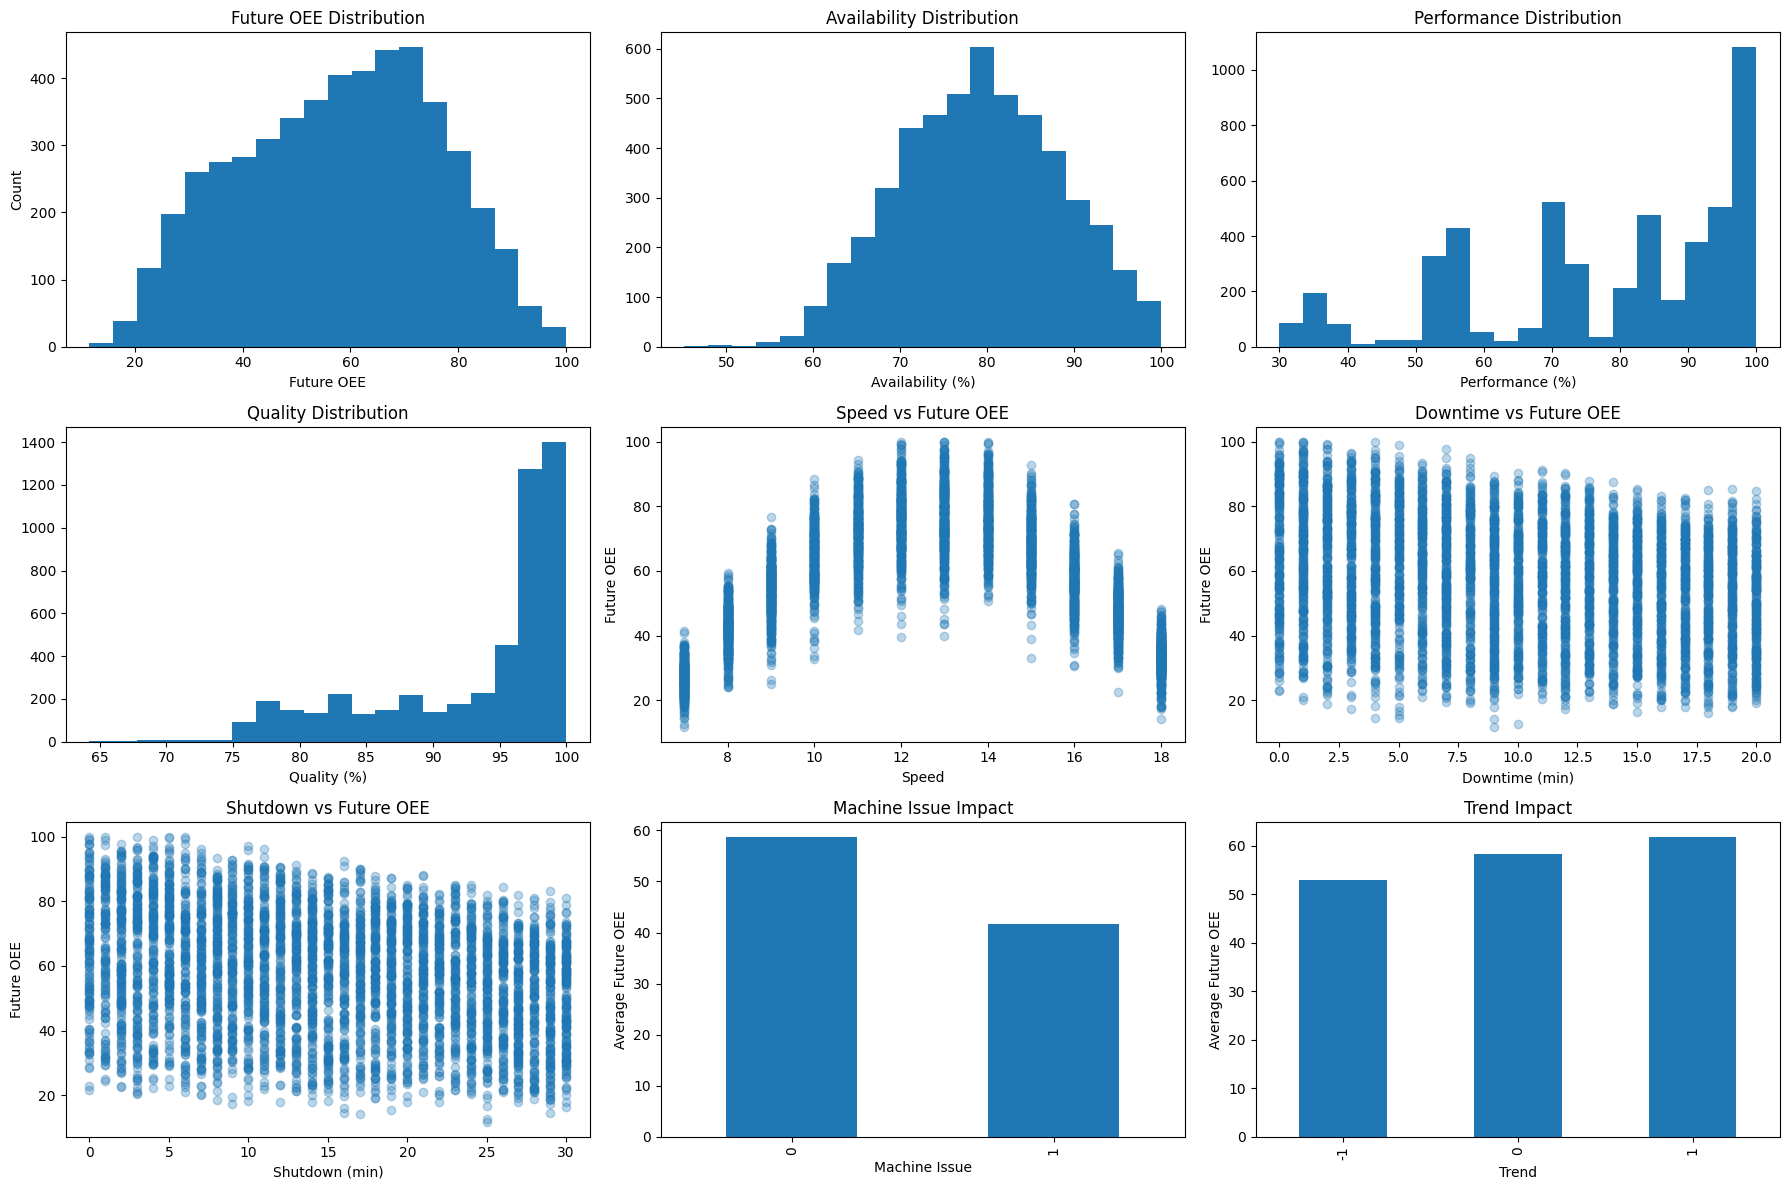

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Future OEE Distribution
axes[0, 0].hist(
    synthetic_df["future_oee"],
    bins=20
)
axes[0, 0].set_title("Future OEE Distribution")
axes[0, 0].set_xlabel("Future OEE")
axes[0, 0].set_ylabel("Count")

# Availability
axes[0, 1].hist(
    synthetic_df["availability"],
    bins=20
)
axes[0, 1].set_title("Availability Distribution")
axes[0, 1].set_xlabel("Availability (%)")

# Performance
axes[0, 2].hist(
    synthetic_df["performance"],
    bins=20
)
axes[0, 2].set_title("Performance Distribution")
axes[0, 2].set_xlabel("Performance (%)")

# Quality
axes[1, 0].hist(
    synthetic_df["quality"],
    bins=20
)
axes[1, 0].set_title("Quality Distribution")
axes[1, 0].set_xlabel("Quality (%)")

# Speed vs Future OEE
axes[1, 1].scatter(
    synthetic_df["speed"],
    synthetic_df["future_oee"],
    alpha=0.3
)
axes[1, 1].set_title("Speed vs Future OEE")
axes[1, 1].set_xlabel("Speed")
axes[1, 1].set_ylabel("Future OEE")

# Downtime vs Future OEE
axes[1, 2].scatter(
    synthetic_df["downtime_minutes"],
    synthetic_df["future_oee"],
    alpha=0.3
)
axes[1, 2].set_title("Downtime vs Future OEE")
axes[1, 2].set_xlabel("Downtime (min)")
axes[1, 2].set_ylabel("Future OEE")

# Shutdown vs Future OEE
axes[2, 0].scatter(
    synthetic_df["shutdown_minutes"],
    synthetic_df["future_oee"],
    alpha=0.3
)
axes[2, 0].set_title("Shutdown vs Future OEE")
axes[2, 0].set_xlabel("Shutdown (min)")
axes[2, 0].set_ylabel("Future OEE")

# Machine Issue Impact
synthetic_df.groupby(
    "machine_issue"
)["future_oee"].mean().plot(
    kind="bar",
    ax=axes[2, 1]
)
axes[2, 1].set_title("Machine Issue Impact")
axes[2, 1].set_xlabel("Machine Issue")
axes[2, 1].set_ylabel("Average Future OEE")

# Trend Impact
synthetic_df.groupby(
    "trend"
)["future_oee"].mean().plot(
    kind="bar",
    ax=axes[2, 2]
)
axes[2, 2].set_title("Trend Impact")
axes[2, 2].set_xlabel("Trend")
axes[2, 2].set_ylabel("Average Future OEE")

plt.tight_layout()
plt.show()

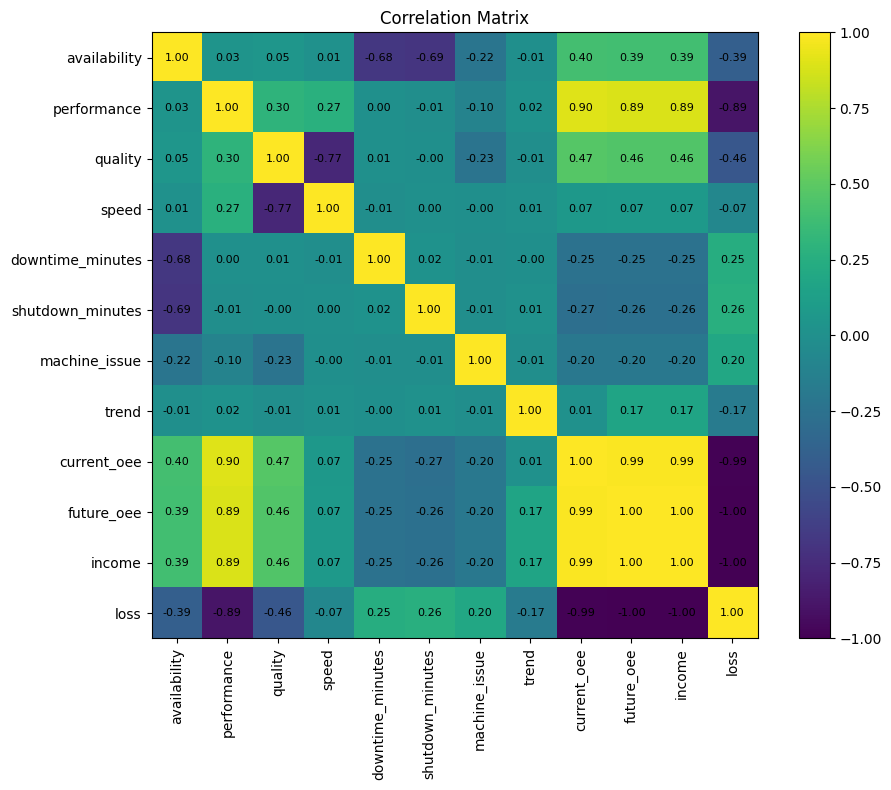

In [ ]:
corr = synthetic_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()

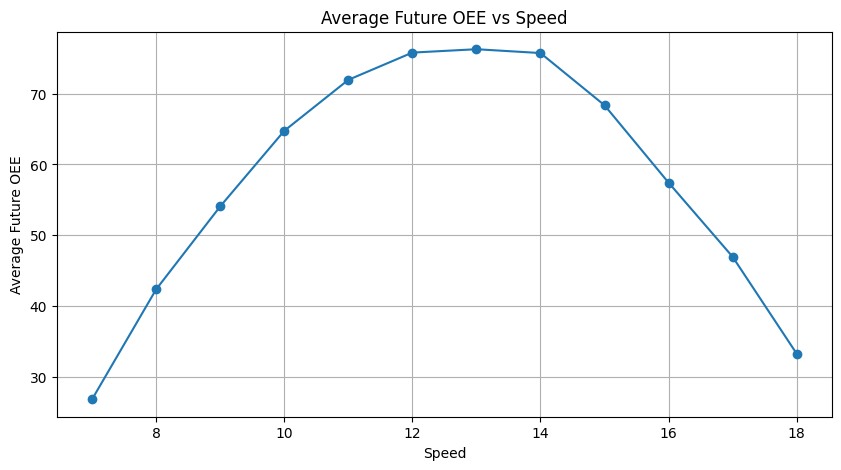

In [91]:
speed_oee = (
    synthetic_df
    .groupby("speed")["future_oee"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    speed_oee.index,
    speed_oee.values,
    marker="o"
)

plt.title(
    "Average Future OEE vs Speed"
)

plt.xlabel("Speed")
plt.ylabel("Average Future OEE")

plt.grid(True)

plt.show()

In [92]:
synthetic_df.to_csv(
    "data/syn_lathe_jsdata.csv",
    index=False
)

print("Saved:", synthetic_df.shape)

Saved: (5000, 12)


In [93]:
pd.read_csv("data/syn_lathe_jsdata.csv").head()

,availability,performance,quality,speed,downtime_minutes,shutdown_minutes,machine_issue,trend,current_oee,future_oee,income,loss
0,97.97,74.25,82.65,17,3,0,0,1,60.12,64.85,3891,2109
1,92.57,85.33,97.30,10,7,4,0,1,76.86,82.35,4940,1060
2,81.96,67.37,80.41,17,17,2,0,-1,44.40,39.48,2368,3632
3,97.24,32.38,100.00,7,0,2,0,-1,31.48,28.38,1702,4298
4,80.18,93.02,91.27,15,19,0,0,0,68.08,68.45,4107,1893


In [ ]:

# TREND GENERATION

# let current = flow.get("OEE");
# let previous = flow.get("prev_OEE");

# let trend = 0;

# if (current > previous)
#     trend = 1;
# else if (current < previous)
#     trend = -1;

# flow.set("prev_OEE", current);